# Credit Card Fraud Detection
**Internship Project**
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

> **Dataset:** Credit Card Fraud Detection — Kaggle (ULB Machine Learning Group)  
> **Objective:** Detect fraudulent credit card transactions using Machine Learning

## CELL 1 — Install & Import Libraries


In [ ]:
# Install imbalanced-learn (for SMOTE — handles class imbalance)
!pip install imbalanced-learn -q

#  Core libraries
import pandas as pd
import numpy as np

#  Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              roc_curve,
                              precision_recall_curve)

#  Handle class imbalance
from imblearn.over_sampling import SMOTE


print('All libraries imported successfully!')

All libraries imported successfully!


## CELL 2 — Load the Dataset


In [ ]:
#  dataset load
df = pd.read_csv('creditcard.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## CELL 3 — Data Cleaning
Check for missing values, duplicates, and understand the dataset structure.

In [ ]:
#  info
print('1 Dataset Info')
print(df.info())

# missing/null values
print('\n 2 Missing Values')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

# duplicate rows
print('\n 3 Duplicate Rows')
print('Number of duplicates:', df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

# class distribution
print('\n 4 Class Distribution')
print(df['Class'].value_counts())
print('\n0 = Normal Transaction | 1 = Fraudulent Transaction')

1 Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


## CELL 4 — Exploratory Data Analysis (EDA)
Visualize the data to understand patterns, distributions, and relationships.


/tmp/ipykernel_5989/2854951841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])


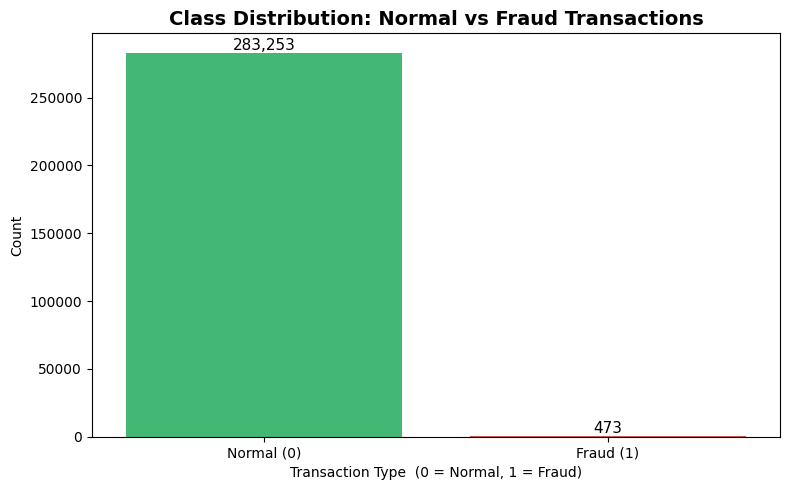

Fraud transactions: 473 (0.17%)
Normal transactions: 283253 (99.83%)


In [ ]:
# Class Distribution (Fraud vs Normal)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution: Normal vs Fraud Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type  (0 = Normal, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])

# count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# percentage
fraud_pct = (df['Class'].sum() / len(df)) * 100
print(f'Fraud transactions: {df["Class"].sum()} ({fraud_pct:.2f}%)')
print(f'Normal transactions: {(df["Class"]==0).sum()} ({100-fraud_pct:.2f}%)')

/tmp/ipykernel_5989/683247459.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1],


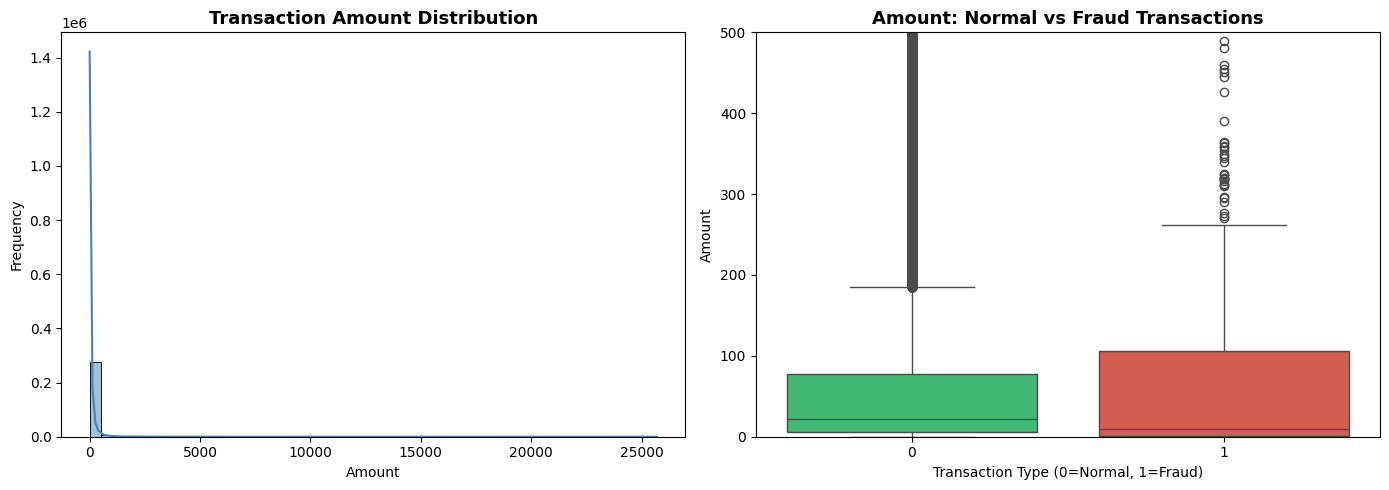

In [ ]:
#  Transaction Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full distribution
sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Right: Fraud vs Normal amounts
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Amount: Normal vs Fraud Transactions', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Type (0=Normal, 1=Fraud)')
axes[1].set_ylabel('Amount')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.savefig('plot2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

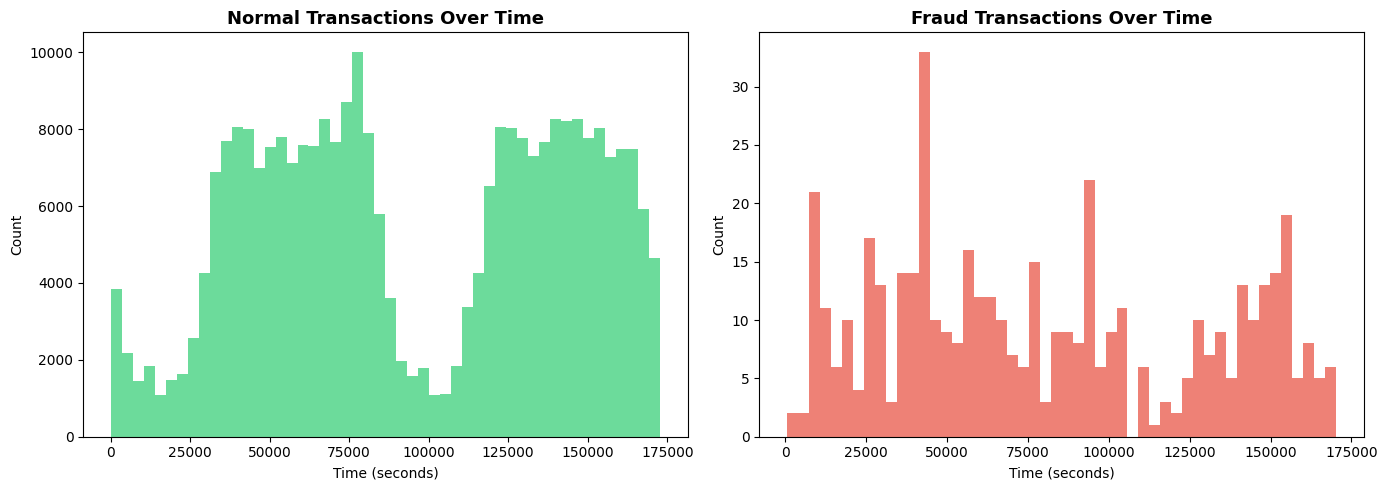

In [ ]:
#  Transaction Time Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions over time
axes[0].hist(df[df['Class']==0]['Time'], bins=50, color='#2ecc71', alpha=0.7)
axes[0].set_title('Normal Transactions Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')

# Fraud transactions over time
axes[1].hist(df[df['Class']==1]['Time'], bins=50, color='#e74c3c', alpha=0.7)
axes[1].set_title('Fraud Transactions Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plot3_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

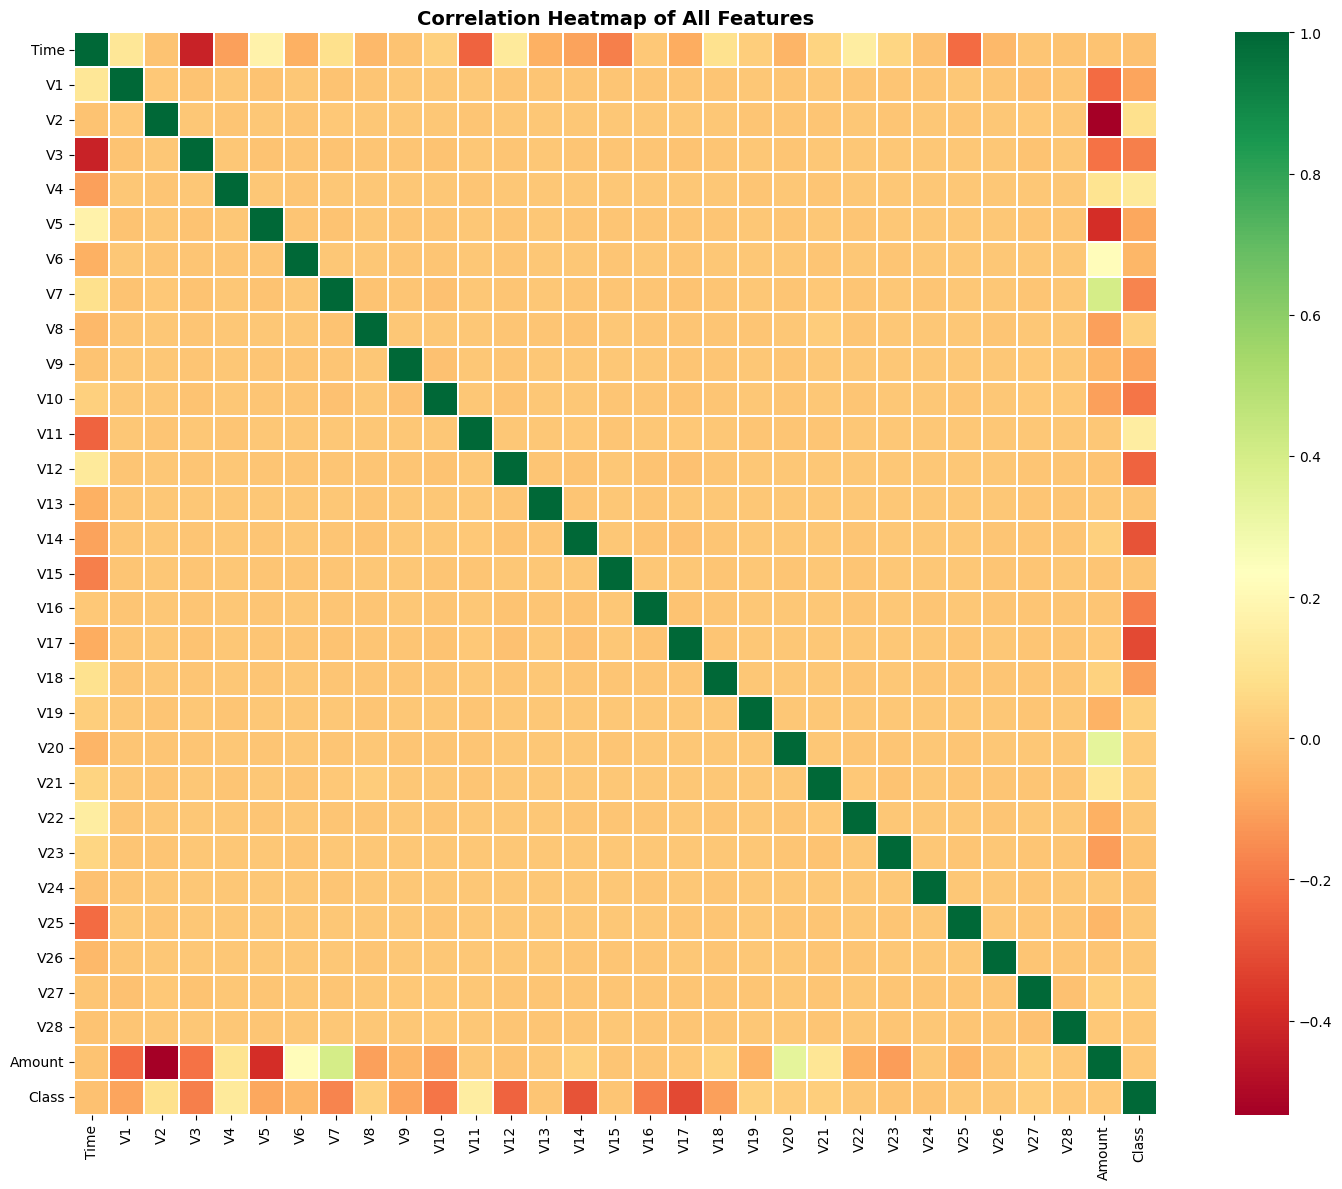

Tip: Look at the last row/column (Class) to see which features correlate with fraud!


In [ ]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix,
            cmap='RdYlGn',
            annot=False,
            linewidths=0.3,
            square=True)
plt.title('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tip: Look at the last row/column (Class) to see which features correlate with fraud!')

/tmp/ipykernel_5989/2067365359.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='RdYlGn_r')


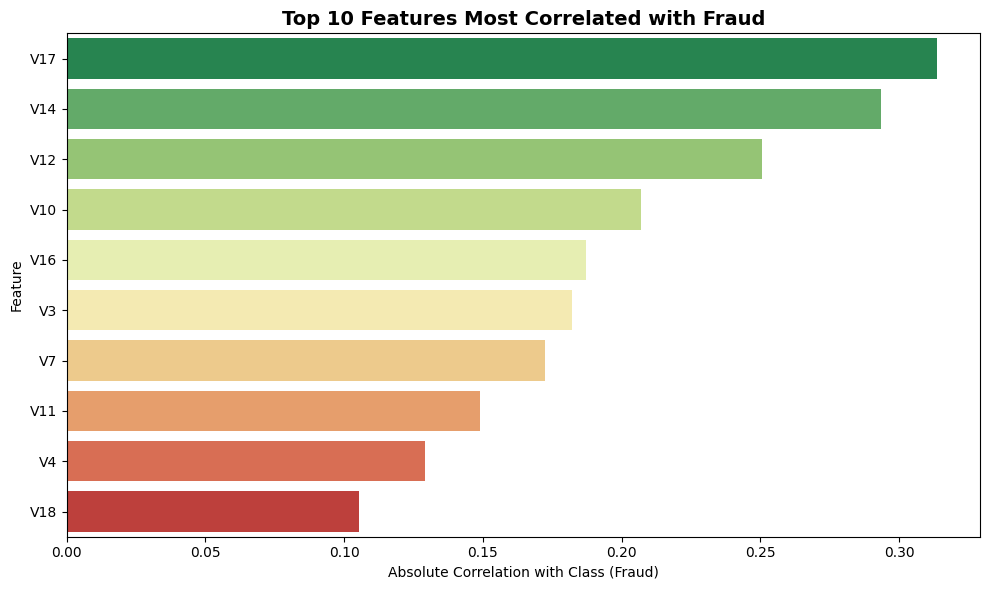

Top 5 features most related to fraud:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
Name: Class, dtype: float64


In [ ]:
#  Top Features Correlated with Fraud
# i Find which features are most correlated with fraud (Class)
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = corr_with_class.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='RdYlGn_r')
plt.title('Top 10 Features Most Correlated with Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation with Class (Fraud)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot5_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features most related to fraud:')
print(top_features.head())

## CELL 5 — Data Preprocessing
Prepare the data for machine learning model:
- Scale Amount and Time
- Split into features (X) and label (y)
- Train/test split
- Handle class imbalance with SMOTE

In [ ]:
#  Scale Amount and Time
# These two columns have very different ranges compared to V1-V28
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])

# Drop the original unscaled columns
df_processed = df.drop(['Amount', 'Time'], axis=1)

print('Preprocessing done. New shape:', df_processed.shape)
print('New columns added: scaled_Amount, scaled_Time')

#  Split features and label
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

print('\nFeatures (X) shape:', X.shape)
print('Labels (y) shape:', y.shape)
print('Fraud cases in full dataset:', y.sum())

Preprocessing done. New shape: (283726, 31)
New columns added: scaled_Amount, scaled_Time

Features (X) shape: (283726, 30)
Labels (y) shape: (283726,)
Fraud cases in full dataset: 473


In [ ]:
#  Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size: ', X_test.shape)
print('\nFraud cases in training set:', y_train.sum())
print('Fraud cases in testing set: ', y_test.sum())

Training set size: (226980, 30)
Testing set size:  (56746, 30)

Fraud cases in training set: 378
Fraud cases in testing set:  95


In [ ]:
#  Handle class imbalance using SMOTE
# SMOTE creates synthetic (fake but realistic) fraud samples
# so the model learns fraud patterns properly
# IMPORTANT: Apply SMOTE ONLY on training data — never on test data!

print('Before SMOTE:')
print('Normal:', (y_train == 0).sum(), '| Fraud:', (y_train == 1).sum())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print('Normal:', (y_train_sm == 0).sum(), '| Fraud:', (y_train_sm == 1).sum())
print('\nNow both classes are balanced — model will learn fraud properly!')

Before SMOTE:
Normal: 226602 | Fraud: 378

After SMOTE:
Normal: 226602 | Fraud: 226602

Now both classes are balanced — model will learn fraud properly!


## CELL 6 — Model Building & Training
Train two models:
1. **Logistic Regression** — simple baseline
2. **Random Forest** —  main model (more powerful)

In [ ]:
#  Logistic Regression (Baseline)
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred = lr_model.predict(X_test)
lr_auc  = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print('\n=== Logistic Regression Results ===')
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC Score: {lr_auc:.4f}')

Training Logistic Regression...

=== Logistic Regression Results ===
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC Score: 0.9619


In [ ]:
#  Random Forest (Main Model)
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_auc  = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print('\n Random Forest Results ')
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC Score: {rf_auc:.4f}')

Training Random Forest...

 Random Forest Results 
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9436


## CELL 7 — Model Evaluation Visualizations


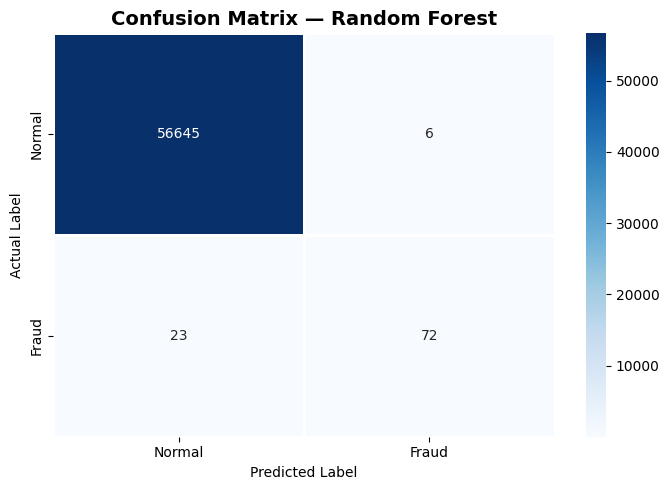

True Negatives (correctly predicted Normal): 56645
False Positives (Normal predicted as Fraud): 6
False Negatives (Fraud predicted as Normal): 23
True Positives (correctly predicted Fraud): 72


In [ ]:
#  Confusion Matrix — Random Forest
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            linewidths=1)
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plot6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('True Negatives (correctly predicted Normal):', cm[0][0])
print('False Positives (Normal predicted as Fraud):', cm[0][1])
print('False Negatives (Fraud predicted as Normal):', cm[1][0])
print('True Positives (correctly predicted Fraud):', cm[1][1])

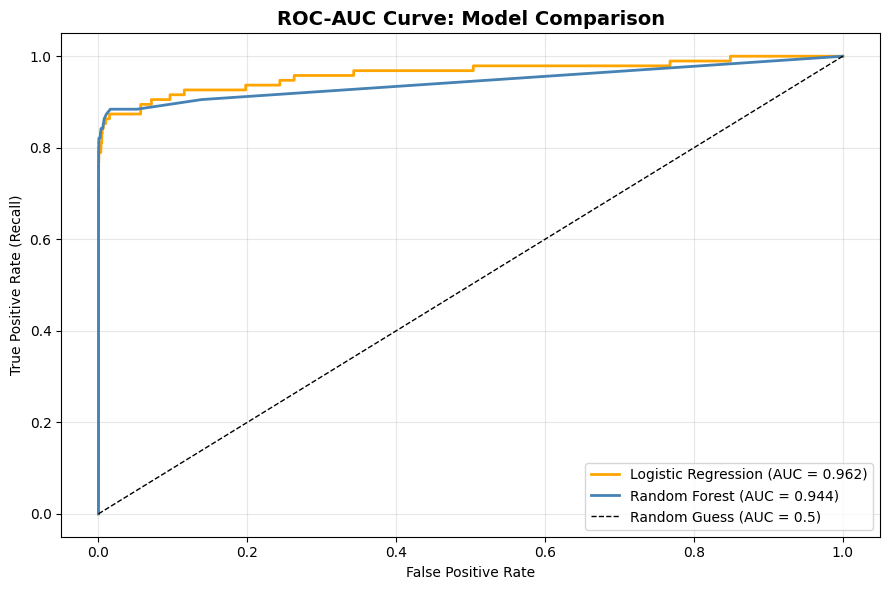

In [ ]:
#  ROC-AUC Curve — Both Models
plt.figure(figsize=(9, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])
plt.plot(fpr_lr, tpr_lr, color='orange', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, color='steelblue', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

# Baseline (random guess)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC = 0.5)')

plt.title('ROC-AUC Curve: Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot7_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_5989/359712980.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Blues_r')


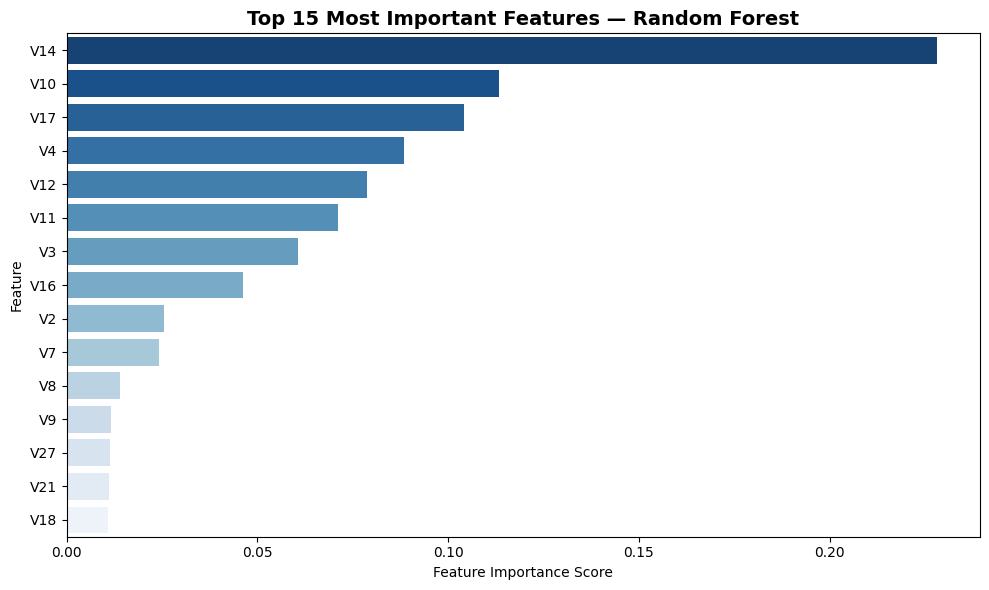

In [ ]:
#  Feature Importance — Random Forest
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='Blues_r')
plt.title('Top 15 Most Important Features — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 8 — Final Summary
Results summary

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('='*55)
print('      CREDIT CARD FRAUD DETECTION — FINAL RESULTS')
print('='*55)
print(f'Dataset: 284,807 transactions | Fraud rate: 0.17%')
print(f'Train size: {len(X_train_sm):,} (after SMOTE) | Test size: {len(X_test):,}')
print('-'*55)
print('MODEL               ACCURACY   PRECISION  RECALL   F1')
print('-'*55)

for name, pred in [('Logistic Regression', lr_pred), ('Random Forest', rf_pred)]:
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    print(f'{name:<20} {acc:.3f}     {prec:.3f}      {rec:.3f}    {f1:.3f}')

print('='*55)
print(f'Best Model: Random Forest | ROC-AUC: {rf_auc:.4f}')


      CREDIT CARD FRAUD DETECTION — FINAL RESULTS
Dataset: 284,807 transactions | Fraud rate: 0.17%
Train size: 453,204 (after SMOTE) | Test size: 56,746
-------------------------------------------------------
MODEL               ACCURACY   PRECISION  RECALL   F1
-------------------------------------------------------
Logistic Regression  0.974     0.053      0.874    0.100
Random Forest        0.999     0.923      0.758    0.832
Best Model: Random Forest | ROC-AUC: 0.9436
